# US EPU Daily - Exploratory Data Analysis

This notebook explores the US Economic Policy Uncertainty (EPU) Daily dataset.

**Dataset:** `us-epu-daily.csv`

**Description:** Daily US Economic Policy Uncertainty Index from 1985 to present.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
DATA_PATH = Path('../../data/raw/us-epu-daily.csv')

## 1. Load Data

In [4]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display first few rows
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,day,month,year,daily_policy_index
0,1,1,1985,103.83
1,2,1,1985,296.43
2,3,1,1985,56.06
3,4,1,1985,118.45
4,5,1,1985,88.56



Last 5 rows:


,day,month,year,daily_policy_index
15003,29,1,2026,240.40
15004,30,1,2026,208.34
15005,31,1,2026,256.07
15006,1,2,2026,303.29
15007,2,2,2026,109.41


## 2. Data Overview

In [5]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names and Types:")
print(df.dtypes)
print("\nDataset Info:")
df.info()

Dataset Shape: (15008, 4)

Column Names and Types:
day                     int64
month                   int64
year                    int64
daily_policy_index    float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15008 entries, 0 to 15007
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   day                 15008 non-null  int64  
 1   month               15008 non-null  int64  
 2   year                15008 non-null  int64  
 3   daily_policy_index  15008 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 469.1 KB


In [6]:
# Create a proper date column
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.sort_values('date').reset_index(drop=True)

print("Date range:", df['date'].min(), "to", df['date'].max())
print("Total days:", len(df))

Date range: 1985-01-01 00:00:00 to 2026-02-02 00:00:00
Total days: 15008


## 3. Missing Values Analysis

In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:


,Missing Count,Percentage



✓ No missing values found!


## 4. Descriptive Statistics

In [8]:
# Statistical summary
print("Descriptive Statistics for daily_policy_index:")
display(df['daily_policy_index'].describe())

# Additional statistics
print("\nAdditional Statistics:")
print(f"Skewness: {df['daily_policy_index'].skew():.4f}")
print(f"Kurtosis: {df['daily_policy_index'].kurtosis():.4f}")
print(f"Coefficient of Variation: {(df['daily_policy_index'].std() / df['daily_policy_index'].mean()):.4f}")

Descriptive Statistics for daily_policy_index:


count    15008.000000
mean       116.799588
std         93.420367
min          3.320000
25%         58.070000
50%         91.155000
75%        144.087500
max       1026.380000
Name: daily_policy_index, dtype: float64


Additional Statistics:
Skewness: 2.6073
Kurtosis: 10.5286
Coefficient of Variation: 0.7998


## 5. Time Series Visualization

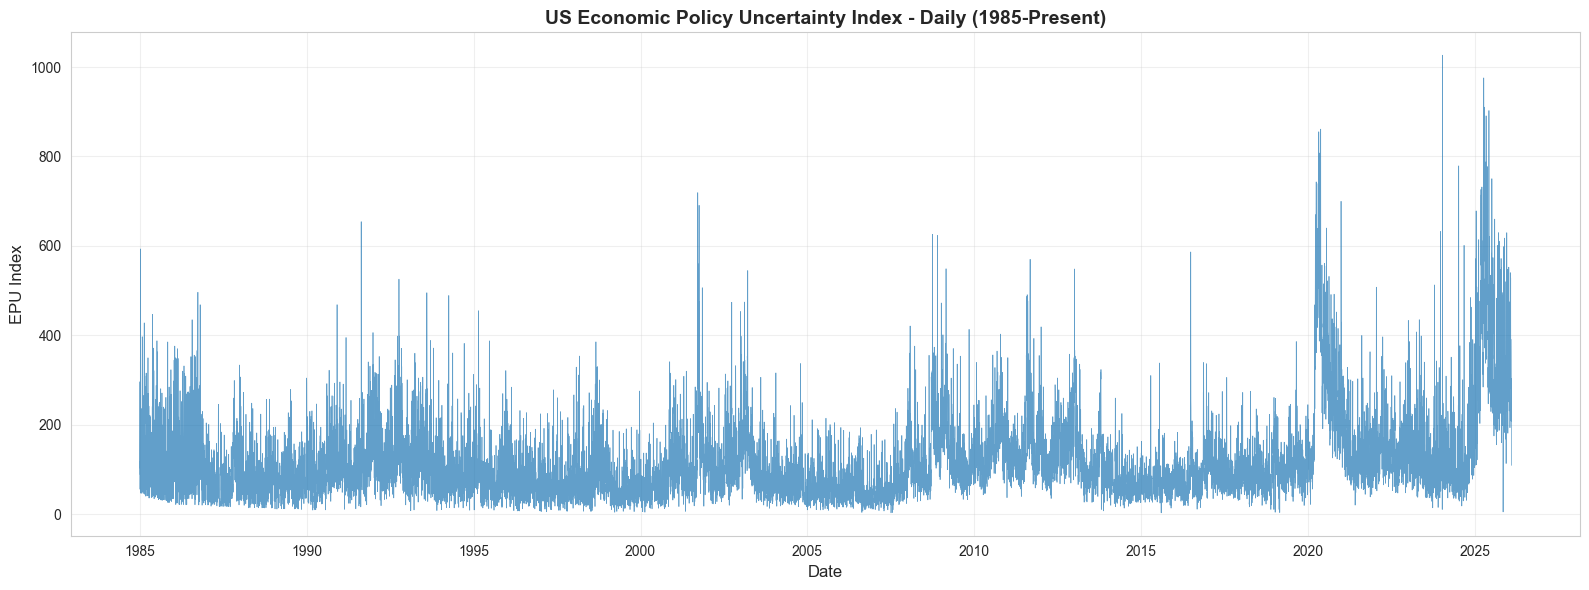

In [9]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['daily_policy_index'], linewidth=0.5, alpha=0.7)
ax.set_title('US Economic Policy Uncertainty Index - Daily (1985-Present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

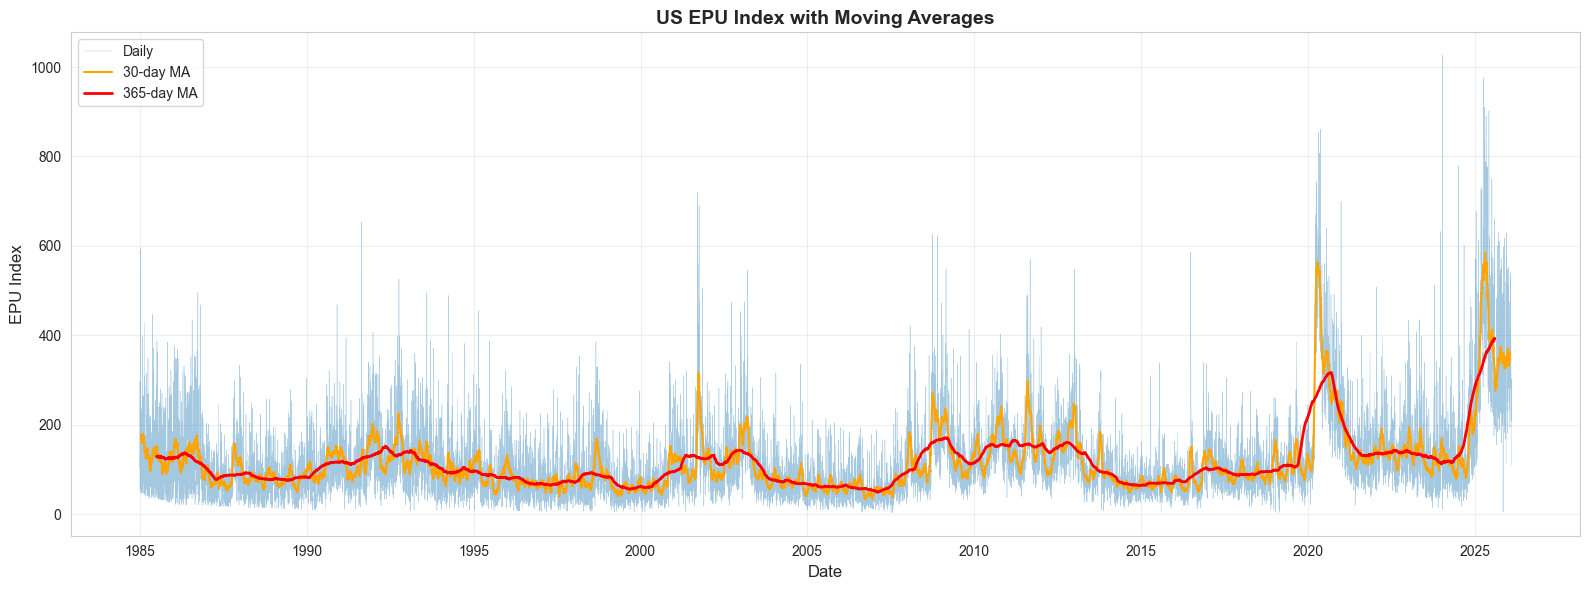

In [10]:
# Plot with rolling average
df['rolling_30d'] = df['daily_policy_index'].rolling(window=30, center=True).mean()
df['rolling_365d'] = df['daily_policy_index'].rolling(window=365, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['daily_policy_index'], linewidth=0.3, alpha=0.4, label='Daily')
ax.plot(df['date'], df['rolling_30d'], linewidth=1.5, label='30-day MA', color='orange')
ax.plot(df['date'], df['rolling_365d'], linewidth=2, label='365-day MA', color='red')
ax.set_title('US EPU Index with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Distribution Analysis

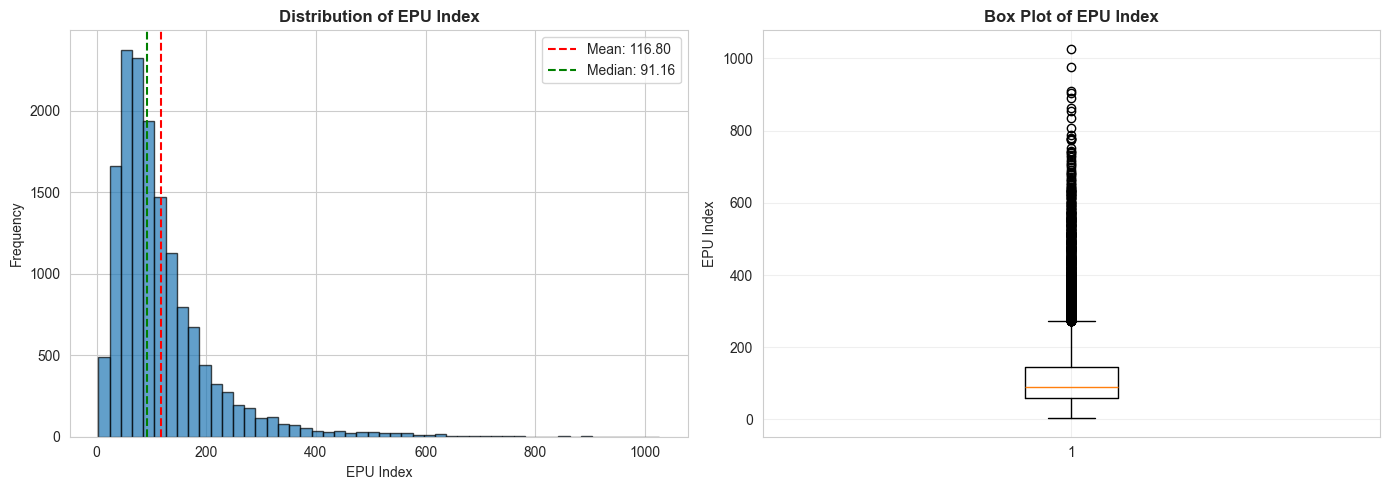

In [11]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['daily_policy_index'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of EPU Index', fontsize=12, fontweight='bold')
axes[0].set_xlabel('EPU Index')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['daily_policy_index'].mean(), color='red', linestyle='--', label=f'Mean: {df["daily_policy_index"].mean():.2f}')
axes[0].axvline(df['daily_policy_index'].median(), color='green', linestyle='--', label=f'Median: {df["daily_policy_index"].median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['daily_policy_index'], vert=True)
axes[1].set_title('Box Plot of EPU Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('EPU Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Temporal Patterns

Yearly Statistics:


,mean,std,min,max,count
year,,,,,
2017,97.784466,44.221739,31.11,305.98,365
2018,92.257014,45.311742,10.92,275.14,365
2019,108.860521,52.210259,4.05,386.19,365
2020,303.718333,160.566510,22.25,861.10,366
2021,139.097781,63.809924,20.63,429.48,365
2022,138.438082,59.275674,47.62,507.73,365
2023,131.141370,80.460533,14.69,632.37,365
2024,130.889891,100.678576,10.92,1026.38,366
2025,384.104795,158.446645,5.39,975.60,365


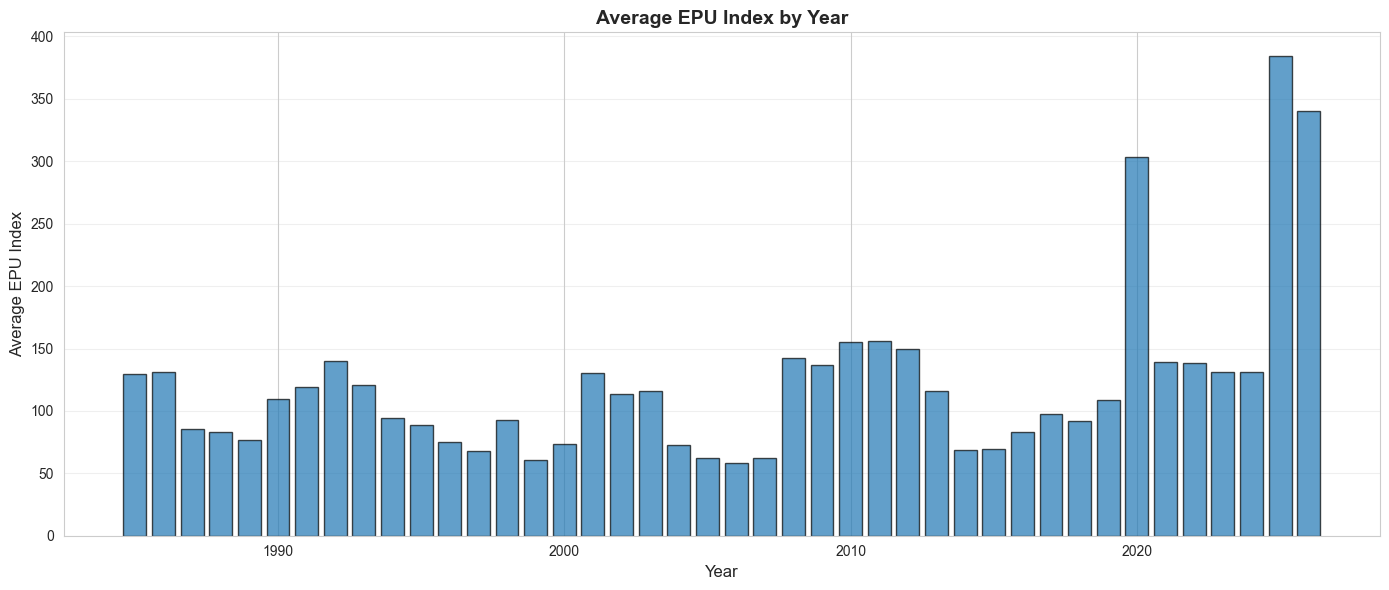

In [12]:
# Yearly statistics
yearly_stats = df.groupby('year')['daily_policy_index'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Yearly Statistics:")
display(yearly_stats.tail(10))

# Plot yearly average
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(yearly_stats.index, yearly_stats['mean'], alpha=0.7, edgecolor='black')
ax.set_title('Average EPU Index by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average EPU Index', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

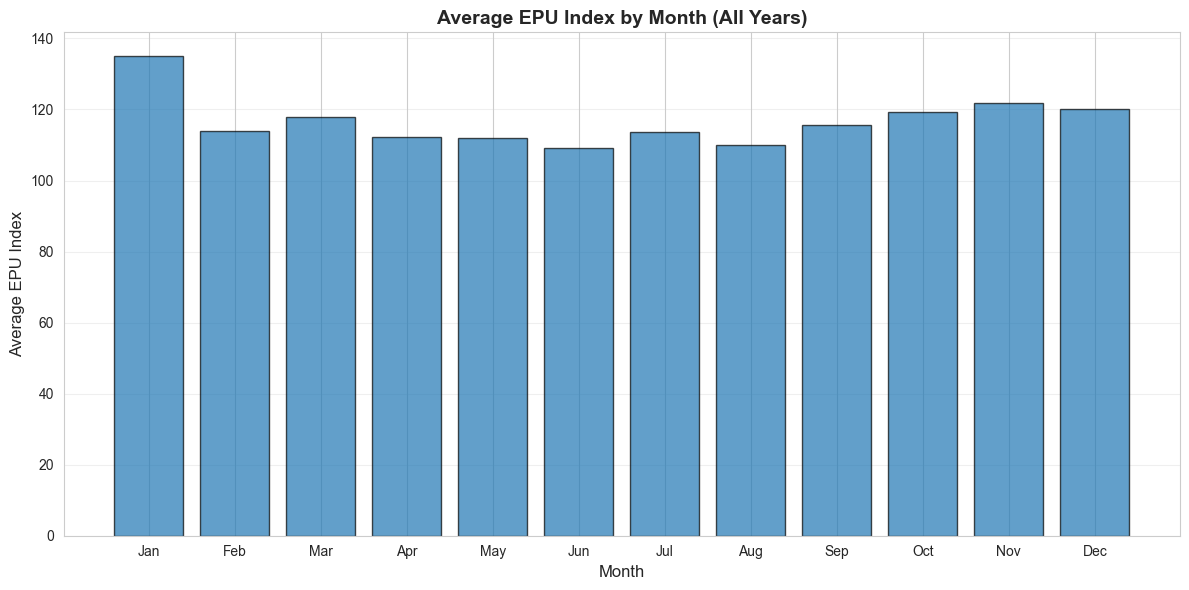

In [13]:
# Monthly patterns
monthly_avg = df.groupby('month')['daily_policy_index'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_avg.index, monthly_avg.values, alpha=0.7, edgecolor='black')
ax.set_title('Average EPU Index by Month (All Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average EPU Index', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Outlier Detection

In [14]:
# Identify outliers using IQR method
Q1 = df['daily_policy_index'].quantile(0.25)
Q3 = df['daily_policy_index'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['daily_policy_index'] < lower_bound) | (df['daily_policy_index'] > upper_bound)]

print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"\nLower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

if len(outliers) > 0:
    print("\nTop 10 highest EPU values:")
    display(df.nlargest(10, 'daily_policy_index')[['date', 'daily_policy_index']])

Number of outliers: 904 (6.02%)

Lower bound: -70.96
Upper bound: 273.11

Top 10 highest EPU values:


,date,daily_policy_index
14252,2024-01-09,1026.38
14704,2025-04-05,975.60
14712,2025-04-13,910.15
14761,2025-06-01,902.62
14730,2025-05-01,890.82
12920,2020-05-17,861.10
12899,2020-04-26,855.17
14710,2025-04-11,833.81
12908,2020-05-05,807.66
14727,2025-04-28,787.79


## 9. Summary and Key Findings

In [15]:
print("=" * 60)
print("KEY FINDINGS - US EPU DAILY")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start Date: {df['date'].min().strftime('%Y-%m-%d')}")
print(f"   - End Date: {df['date'].max().strftime('%Y-%m-%d')}")
print(f"   - Total Days: {len(df):,}")

print(f"\n2. EPU Index Statistics:")
print(f"   - Mean: {df['daily_policy_index'].mean():.2f}")
print(f"   - Median: {df['daily_policy_index'].median():.2f}")
print(f"   - Std Dev: {df['daily_policy_index'].std():.2f}")
print(f"   - Min: {df['daily_policy_index'].min():.2f}")
print(f"   - Max: {df['daily_policy_index'].max():.2f}")

print(f"\n3. Data Quality:")
print(f"   - Missing Values: {df.isnull().sum().sum()}")
print(f"   - Outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

print(f"\n4. Temporal Insights:")
print(f"   - Year with highest avg EPU: {yearly_stats['mean'].idxmax()} ({yearly_stats['mean'].max():.2f})")
print(f"   - Year with lowest avg EPU: {yearly_stats['mean'].idxmin()} ({yearly_stats['mean'].min():.2f})")
print(f"   - Month with highest avg EPU: {monthly_avg.idxmax()} ({monthly_avg.max():.2f})")
print(f"   - Month with lowest avg EPU: {monthly_avg.idxmin()} ({monthly_avg.min():.2f})")

print("\n" + "=" * 60)

KEY FINDINGS - US EPU DAILY

1. Dataset Coverage:
   - Start Date: 1985-01-01
   - End Date: 2026-02-02
   - Total Days: 15,008

2. EPU Index Statistics:
   - Mean: 116.80
   - Median: 91.16
   - Std Dev: 93.42
   - Min: 3.32
   - Max: 1026.38

3. Data Quality:
   - Missing Values: 393
   - Outliers (IQR method): 904 (6.02%)

4. Temporal Insights:
   - Year with highest avg EPU: 2025 (384.10)
   - Year with lowest avg EPU: 2006 (57.99)
   - Month with highest avg EPU: 1 (134.97)
   - Month with lowest avg EPU: 6 (109.07)

